# Taxi-v4 RL - Notebook demo

Doel: een korte, reproduceerbare workflow laten zien die de kern van het project aantoont.

Wat je hier ziet:
- omgeving en state-decoding
- baseline agents (random, heuristiek)
- korte Q-learning training run
- evaluatie en simpele visualisatie

## Setup
Zorg dat je dependencies zijn geinstalleerd via `pip install -r requirements.txt`.
De notebook gebruikt de code uit de map `src/` en schrijft demo-resultaten naar `results/notebook_demo`.

In [13]:
from pathlib import Path
import sys
import subprocess

# Zoek requirements.txt in huidige map of een map hoger.
req = Path("requirements.txt")
if not req.exists():
    req = Path("..") / "requirements.txt"

subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req)])

did_reinstall = False
try:
    import numpy as np
    _ = np.random.RandomState(0)
except Exception:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--force-reinstall", "--no-cache-dir", "numpy"
    ])
    did_reinstall = True

if did_reinstall:
    print("Numpy herinstallatie gedaan. Herstart de kernel en run deze cel opnieuw.")

In [14]:
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import yaml

# Zorg dat we vanuit de notebook de src/ modules kunnen importeren.
project_root = Path('..').resolve()
if not (project_root / 'src').exists():
    project_root = Path('.').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.env import TaxiEnv, N_ACTIONS, N_STATES, ACTION_NAMES, decode_state
from src.agents.q_learning import QLearningAgent
from src.agents.random_agent import RandomAgent
from src.agents.heuristic_agent import HeuristicAgent

n_actions = N_ACTIONS
n_states = N_STATES
action_names = ACTION_NAMES

results_dir = project_root / 'results' / 'notebook_demo'
results_dir.mkdir(parents=True, exist_ok=True)

## 1) Omgeving check
We tonen een reset, een actie en de state-decoding.

In [15]:
env = TaxiEnv()
s0 = env.reset(seed=0)
decoded = decode_state(s0)

print('start state:', s0, 'decoded:', decoded)
print('action 0 =', action_names[0])

s1, reward, done, info = env.step(0)  # 0 = south
env.close()

print('step -> state:', s1, 'reward:', reward, 'done:', done)
print('info:', info)

start state: 314 decoded: (3, 0, 3, 2)
action 0 = south
step -> state: 414 reward: -1.0 done: False
info: {'prob': 1.0, 'action_mask': array([0, 1, 0, 0, 0, 0], dtype=int8), 'illegal_action': False, 'delivered': False}


## 2) Baselines (random en heuristiek)
We draaien een korte evaluatie om te laten zien dat de agents werken.

In [16]:
def evaluate_agent(agent, episodes=50, seed=0, max_steps=200):
    """Evaluate an agent over multiple episodes and return summary stats."""
    env = TaxiEnv()
    returns = []
    lengths = []
    illegals = []
    success = []
    for ep in range(episodes):
        state = env.reset(seed=seed + ep)
        ep_return = 0.0
        steps = 0
        illegal = 0
        delivered = 0
        for _ in range(max_steps):
            action = agent.select_action(state, greedy=True)
            state, reward, done, info = env.step(action)
            ep_return += reward
            steps += 1
            if info.get('illegal_action'):
                illegal += 1
            if info.get('delivered'):
                delivered = 1
            if done:
                break
        returns.append(ep_return)
        lengths.append(steps)
        illegals.append(illegal)
        success.append(delivered)
    env.close()
    return {
        'return_mean': float(np.mean(returns)),
        'return_std': float(np.std(returns)),
        'len_mean': float(np.mean(lengths)),
        'illegal_mean': float(np.mean(illegals)),
        'success_rate': float(np.mean(success)),
    }

random_agent = RandomAgent(seed=0)
heuristic_agent = HeuristicAgent(seed=0)

baseline_results = {
    'random': evaluate_agent(random_agent, episodes=50, seed=0),
    'heuristic': evaluate_agent(heuristic_agent, episodes=50, seed=0),
}
baseline_results

{'random': {'return_mean': -771.54,
  'return_std': 79.05016382019711,
  'len_mean': 198.9,
  'illegal_mean': 63.72,
  'success_rate': 0.04},
 'heuristic': {'return_mean': -149.28,
  'return_std': 90.26583849940133,
  'len_mean': 154.32,
  'illegal_mean': 0.0,
  'success_rate': 0.24}}

## 3) Korte Q-learning training run
We trainen kort (klein aantal episodes) zodat dit snel draait in een demo.

In [17]:
def train_qlearning(episodes=300, max_steps=200, seed=0, cfg=None):
    """Train a Q-learning agent and return (agent, log_array)."""
    if cfg is None:
        cfg = {}
    random.seed(seed)
    np.random.seed(seed)
    env = TaxiEnv()
    agent = QLearningAgent(n_states=n_states, n_actions=n_actions, seed=seed, **cfg)
    log = []
    for ep in range(episodes):
        state = env.reset(seed=seed + ep)
        action = agent.select_action(state)
        ep_return = 0.0
        steps = 0
        illegal = 0
        delivered = 0

        for _ in range(max_steps):
            next_state, reward, done, info = env.step(action)
            ep_return += reward
            steps += 1
            if info.get('illegal_action'):
                illegal += 1
            if info.get('delivered'):
                delivered = 1

            agent.update(state, action, reward, next_state, None, done)
            action = agent.select_action(next_state) if not done else 0
            state = next_state
            if done:
                break

        agent.end_episode()
        log.append((ep, ep_return, steps, illegal, delivered, agent.epsilon))

    env.close()
    return agent, np.array(log, dtype=float)

cfg_path = project_root / 'experiments' / 'qlearning_default.yaml'
cfg = {}
if cfg_path.exists():
    with open(cfg_path, 'r') as f:
        cfg = (yaml.safe_load(f) or {}).get('agent', {})

agent, log = train_qlearning(episodes=300, seed=0, cfg=cfg)
log[:5]

array([[   0.      , -821.      ,  200.      ,   69.      ,    0.      ,
           0.999525],
       [   1.      , -659.      ,  200.      ,   51.      ,    0.      ,
           0.99905 ],
       [   2.      , -713.      ,  200.      ,   57.      ,    0.      ,
           0.998575],
       [   3.      , -749.      ,  200.      ,   61.      ,    0.      ,
           0.9981  ],
       [   4.      , -803.      ,  200.      ,   67.      ,    0.      ,
           0.997625]])

## 4) Plot training curve
We maken een eenvoudige rolling-mean plot van de returns.

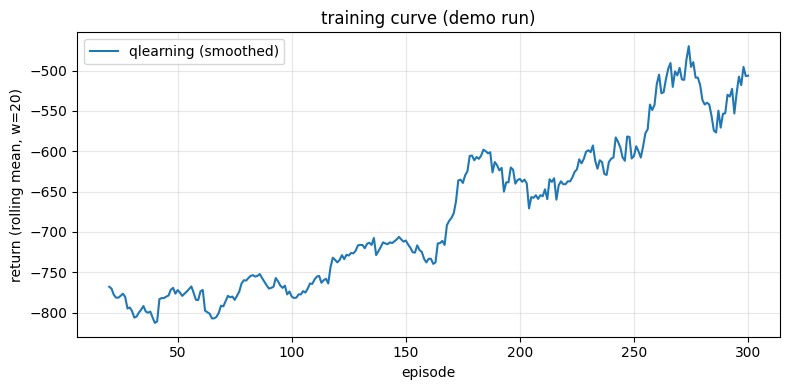

In [18]:
def smooth(x, window=20):
    """Return rolling mean (simple moving average) of x with given window."""
    if window <= 1 or len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode='valid')

returns = log[:, 1]
window = 20
smoothed = smooth(returns, window=window)
x = np.arange(len(smoothed)) + window

plt.figure(figsize=(8, 4))
plt.plot(x, smoothed, label='qlearning (smoothed)')
plt.xlabel('episode')
plt.ylabel(f'return (rolling mean, w={window})')
plt.title('training curve (demo run)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

## 5) Evaluatie van de getrainde agent
We zetten epsilon naar 0 zodat de policy greedy is tijdens evaluatie.

In [19]:
agent.epsilon = 0.0
trained_stats = evaluate_agent(agent, episodes=50, seed=123)
trained_stats

{'return_mean': -82.88,
 'return_std': 103.83691829017269,
 'len_mean': 94.64,
 'illegal_mean': 0.0,
 'success_rate': 0.56}

## 6) Policy visualisatie
We gebruiken het bestaande script `src.plot_policy` om een grid te renderen.

(np.float64(-0.5), np.float64(1919.5), np.float64(839.5), np.float64(-0.5))

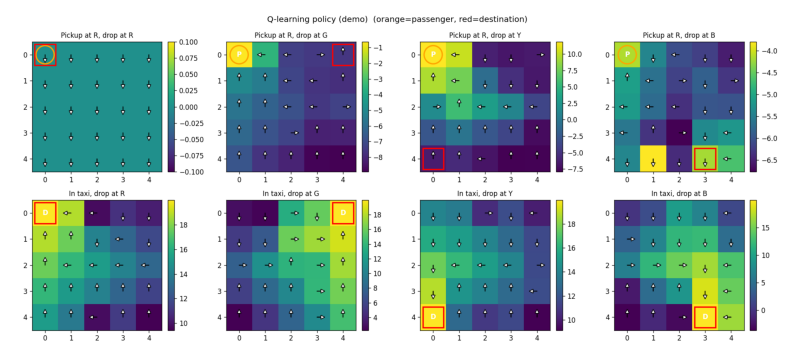

In [20]:
import subprocess

weights_path = results_dir / 'qtable.npy'
agent.save(str(weights_path))

policy_path = results_dir / 'policy.png'
subprocess.run(
    [sys.executable, '-m', 'src.plot_policy',
     '--weights', str(weights_path),
     '--output', str(policy_path),
     '--title', 'Q-learning policy (demo)'],
    check=True,
 )

img = plt.imread(policy_path)
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')